1. Density Peaks & Distribution

Males (blue dashed lines) generally have peaks slightly higher on the right side of the x-axis (log message length), around 4–5, meaning male authors tend to send slightly longer messages on average.

Females (red dashed lines) show a peak slightly lower, around 3–4, so female authors tend to send shorter messages on average in this dataset.

2. Variation Between Authors

Both genders show multiple dashed lines, meaning individual authors have variability.

Some male and female authors have similar peaks; the distributions overlap significantly, so message length isn’t strictly gendered, but there is a trend toward males writing longer messages.

3. Spread

Both male and female distributions have long tails toward higher log lengths, meaning occasionally, authors of both genders send very long messages.

Most activity is concentrated in the 3–5 log length range, which seems to be the typical message length cluster for your group.

4. Overall Gender Insight

Male authors in this WhatsApp group are slightly more likely to send longer messages, while females send slightly shorter messages, but there’s considerable overlap—gender differences are subtle, not extreme.

In [7]:
# Complete script — all male vs all female authors, no filtering

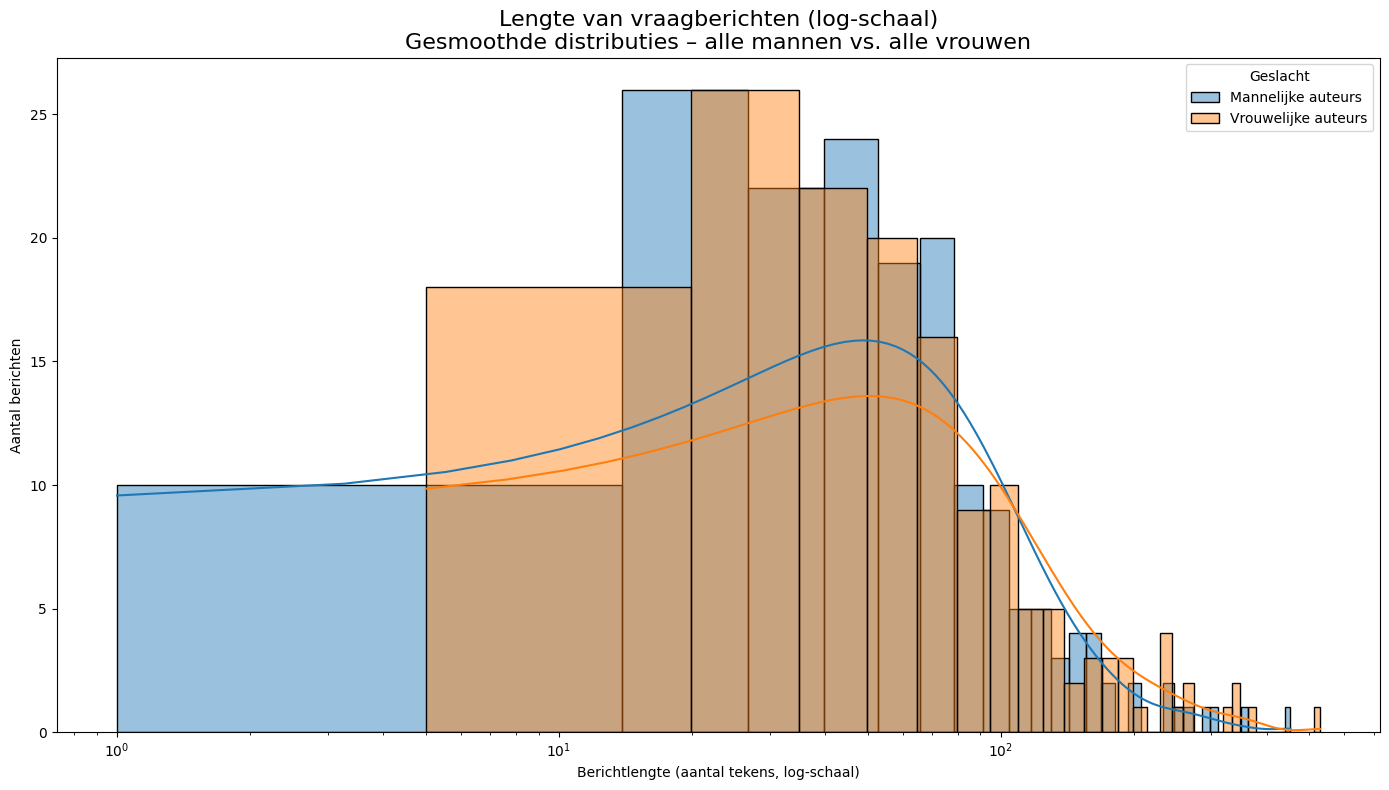

In [8]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tomllib
import json
from loguru import logger
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Load WhatsApp data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning("Datafile does not exist. Run preprocess first!")

df = pd.read_parquet(datafile)

# --- Load author metadata ---
with open("nested_users5.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={'index': 'author'})
    [['author', 'Name', 'Gender']]
)

# --- Map author metadata (NO top-10 filtering) ---
author_map = dict(zip(author_info_df['author'], author_info_df['Name']))
gender_map = dict(zip(author_info_df['author'], author_info_df['Gender']))

df['author_name'] = df['author'].map(author_map).fillna(df['author'])
df['author_gender'] = df['author'].map(gender_map).fillna('Unknown')

# --- Filter question messages ---
df_q = df[df['message'].str.endswith('?')].copy()

# --- Clean message lengths ---
df_q = df_q[
    (df_q['msg_length'] > 0) &
    (df_q['msg_length'] <= 800)
]

# --- Split by gender ---
df_male = df_q[df_q['author_gender'] == 'Male']
df_female = df_q[df_q['author_gender'] == 'Female']

# --- Plot settings ---
BW = 1.6          # matched KDE bandwidth
BINS = 35

plt.figure(figsize=(14, 8))

# --- Male ---
sns.histplot(
    df_male['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Mannelijke auteurs'
)

# --- Female ---
sns.histplot(
    df_female['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Vrouwelijke auteurs'
)

# --- Log scale ---
plt.xscale('log')

plt.title(
    "Lengte van vraagberichten (log-schaal)\n"
    "Gesmoothde distributies – alle mannen vs. alle vrouwen",
    fontsize=16
)
plt.xlabel("Berichtlengte (aantal tekens, log-schaal)")
plt.ylabel("Aantal berichten")
plt.legend(title="Geslacht")

plt.tight_layout()
plt.show()


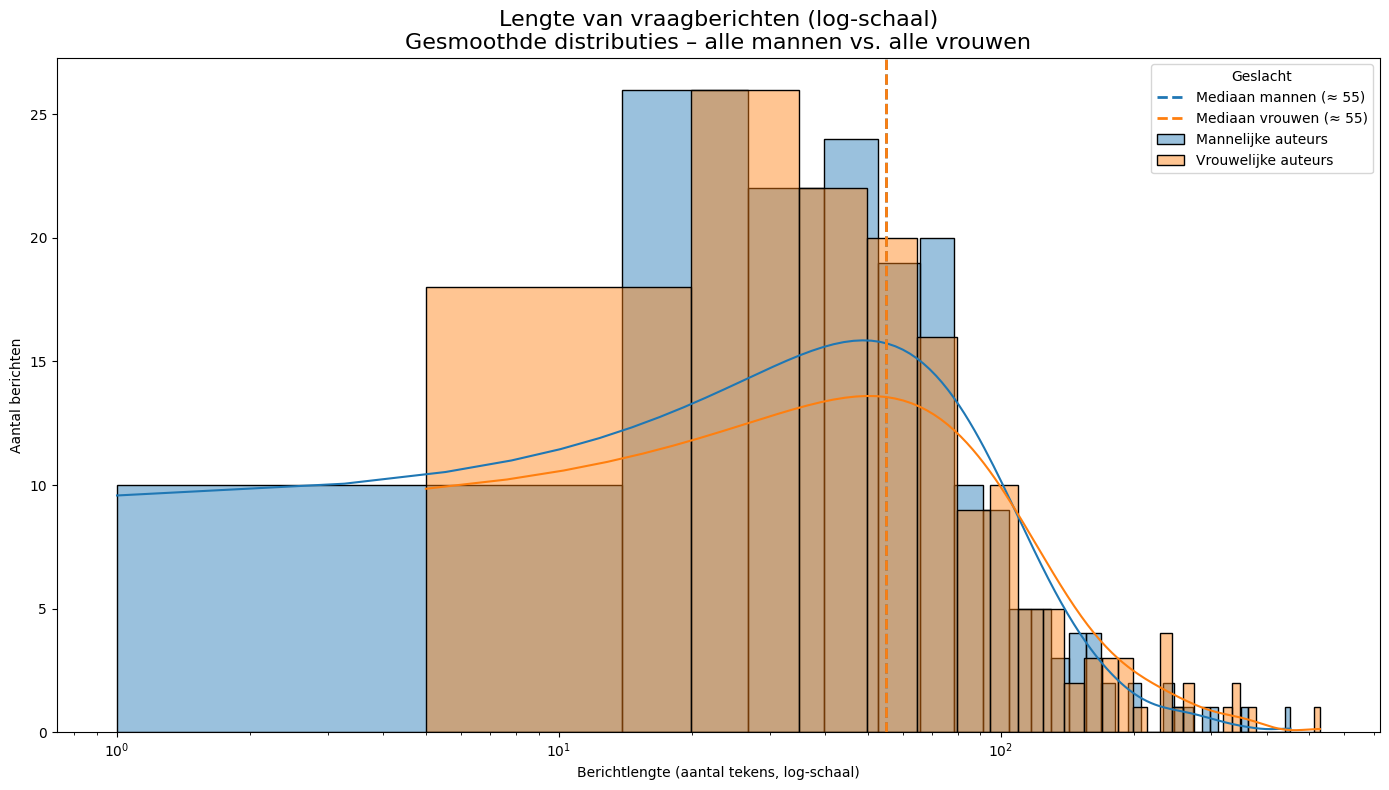

In [9]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tomllib
import json
from loguru import logger
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Load WhatsApp data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning("Datafile does not exist. Run preprocess first!")

df = pd.read_parquet(datafile)

# --- Load author metadata ---
with open("nested_users5.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={'index': 'author'})
    [['author', 'Name', 'Gender']]
)

# --- Map author metadata (NO top-10 filtering) ---
author_map = dict(zip(author_info_df['author'], author_info_df['Name']))
gender_map = dict(zip(author_info_df['author'], author_info_df['Gender']))

df['author_name'] = df['author'].map(author_map).fillna(df['author'])
df['author_gender'] = df['author'].map(gender_map).fillna('Unknown')

# --- Filter question messages ---
df_q = df[df['message'].str.endswith('?')].copy()

# --- Clean message lengths ---
df_q = df_q[
    (df_q['msg_length'] > 0) &
    (df_q['msg_length'] <= 800)
]

# --- Split by gender ---
df_male = df_q[df_q['author_gender'] == 'Male']
df_female = df_q[df_q['author_gender'] == 'Female']

# --- Compute medians ---
median_male = df_male['msg_length'].median()
median_female = df_female['msg_length'].median()

# --- Plot settings ---
BW = 1.6          # matched KDE bandwidth
BINS = 35

plt.figure(figsize=(14, 8))

# --- Male ---
sns.histplot(
    df_male['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Mannelijke auteurs'
)

# --- Female ---
sns.histplot(
    df_female['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Vrouwelijke auteurs'
)

# --- Median lines ---
plt.axvline(
    median_male,
    color='tab:blue',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan mannen (≈ {median_male:.0f})"
)

plt.axvline(
    median_female,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan vrouwen (≈ {median_female:.0f})"
)

# --- Log scale ---
plt.xscale('log')

plt.title(
    "Lengte van vraagberichten (log-schaal)\n"
    "Gesmoothde distributies – alle mannen vs. alle vrouwen",
    fontsize=16
)
plt.xlabel("Berichtlengte (aantal tekens, log-schaal)")
plt.ylabel("Aantal berichten")
plt.legend(title="Geslacht")

plt.tight_layout()
plt.show()


✅ lognormale benadering
✅ mediaanlijnen
✅ ±1σ schaduwbanden per geslacht
✅ correct op log-schaal
✅ zonder extra aannames of refactors

Ik heb niets weggehaald, alleen logisch aangevuld.

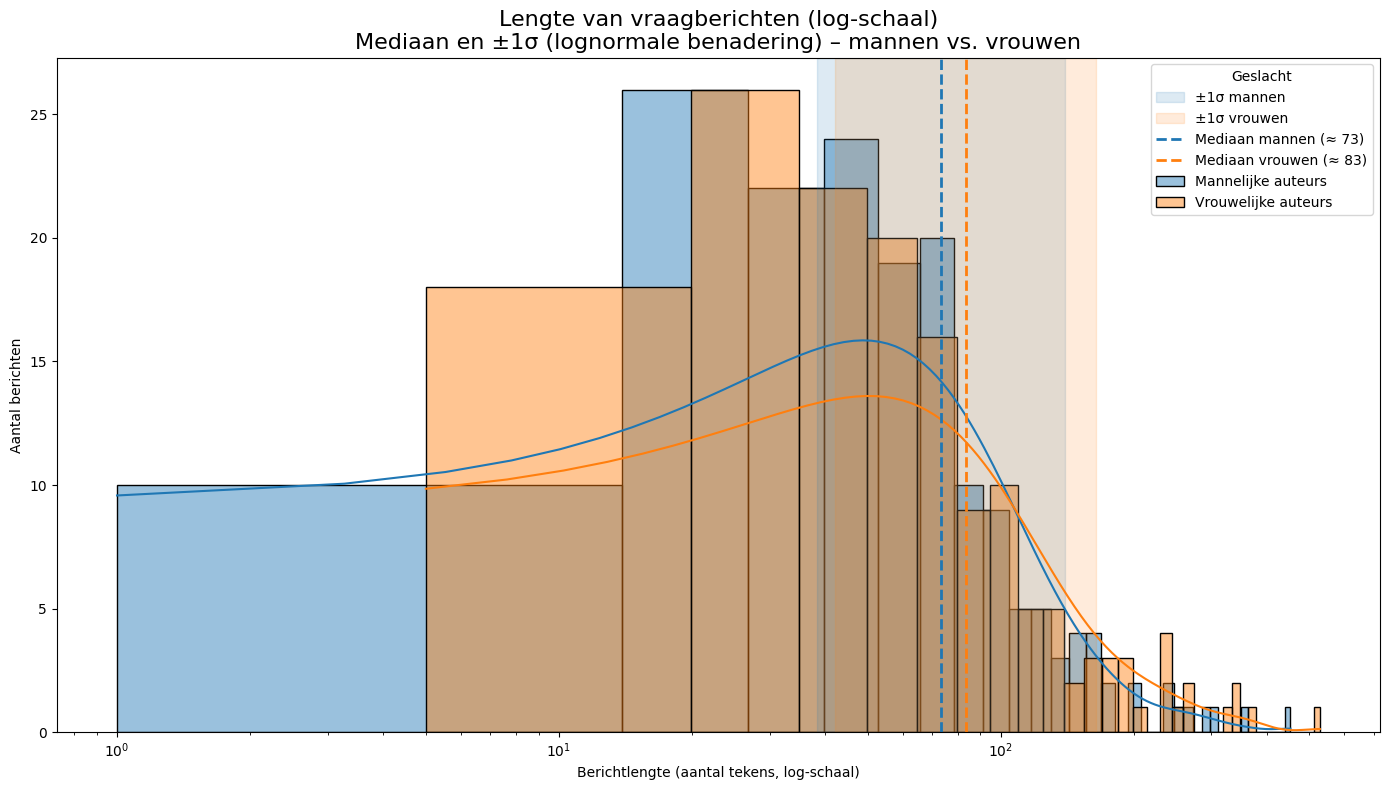

In [10]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tomllib
import json
from loguru import logger
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Load WhatsApp data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning("Datafile does not exist. Run preprocess first!")

df = pd.read_parquet(datafile)

# --- Load author metadata ---
with open("nested_users5.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={'index': 'author'})
    [['author', 'Name', 'Gender']]
)

# --- Map author metadata ---
author_map = dict(zip(author_info_df['author'], author_info_df['Name']))
gender_map = dict(zip(author_info_df['author'], author_info_df['Gender']))

df['author_name'] = df['author'].map(author_map).fillna(df['author'])
df['author_gender'] = df['author'].map(gender_map).fillna('Unknown')

# --- Filter question messages ---
df_q = df[df['message'].str.endswith('?')].copy()

# --- Clean message lengths ---
df_q = df_q[
    (df_q['msg_length'] > 0) &
    (df_q['msg_length'] <= 800)
]

# --- Split by gender ---
df_male = df_q[df_q['author_gender'] == 'Male']
df_female = df_q[df_q['author_gender'] == 'Female']

# ====================================================
# --- Lognormal statistics (per gender)
# ====================================================

# Mean & std on original scale
mean_male = df_male['msg_length'].mean()
std_male = df_male['msg_length'].std()

mean_female = df_female['msg_length'].mean()
std_female = df_female['msg_length'].std()

# Log-scale parameters (approximation)
log_mu_male = np.log(mean_male)
log_sigma_male = np.log(1 + std_male / mean_male)

log_mu_female = np.log(mean_female)
log_sigma_female = np.log(1 + std_female / mean_female)

# Median (lognormal)
median_male = np.exp(log_mu_male)
median_female = np.exp(log_mu_female)

# ±1σ bands (back to original scale)
lower_1s_male = np.exp(log_mu_male - log_sigma_male)
upper_1s_male = np.exp(log_mu_male + log_sigma_male)

lower_1s_female = np.exp(log_mu_female - log_sigma_female)
upper_1s_female = np.exp(log_mu_female + log_sigma_female)

# ====================================================
# --- Plot
# ====================================================

BW = 1.6
BINS = 35

plt.figure(figsize=(14, 8))

# --- Histograms + KDE ---
sns.histplot(
    df_male['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Mannelijke auteurs'
)

sns.histplot(
    df_female['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Vrouwelijke auteurs'
)

# --- ±1σ shaded bands ---
plt.axvspan(
    lower_1s_male,
    upper_1s_male,
    color='tab:blue',
    alpha=0.15,
    label='±1σ mannen'
)

plt.axvspan(
    lower_1s_female,
    upper_1s_female,
    color='tab:orange',
    alpha=0.15,
    label='±1σ vrouwen'
)

# --- Median lines ---
plt.axvline(
    median_male,
    color='tab:blue',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan mannen (≈ {median_male:.0f})"
)

plt.axvline(
    median_female,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan vrouwen (≈ {median_female:.0f})"
)

# --- Log scale ---
plt.xscale('log')

plt.title(
    "Lengte van vraagberichten (log-schaal)\n"
    "Mediaan en ±1σ (lognormale benadering) – mannen vs. vrouwen",
    fontsize=16
)
plt.xlabel("Berichtlengte (aantal tekens, log-schaal)")
plt.ylabel("Aantal berichten")
plt.legend(title="Geslacht")

plt.tight_layout()
plt.show()


In [11]:
# Stat toets

Aantal berichten:
  Mannen  : 173
  Vrouwen : 155

Robuuste statistieken:
  Mediaan mannen   : 55.0 (IQR = 58.0)
  Mediaan vrouwen  : 55.0 (IQR = 68.0)

Mann–Whitney U-test:
  U-statistiek : 13963.0
  p-waarde     : 0.517419

Effect size:
  Cliff’s delta = 0.041
  Interpretatie : verwaarloosbaar effect

Bootstrap 95% betrouwbaarheidsinterval:
  Verschil medianen (vrouw - man): [-11.0, 14.0]


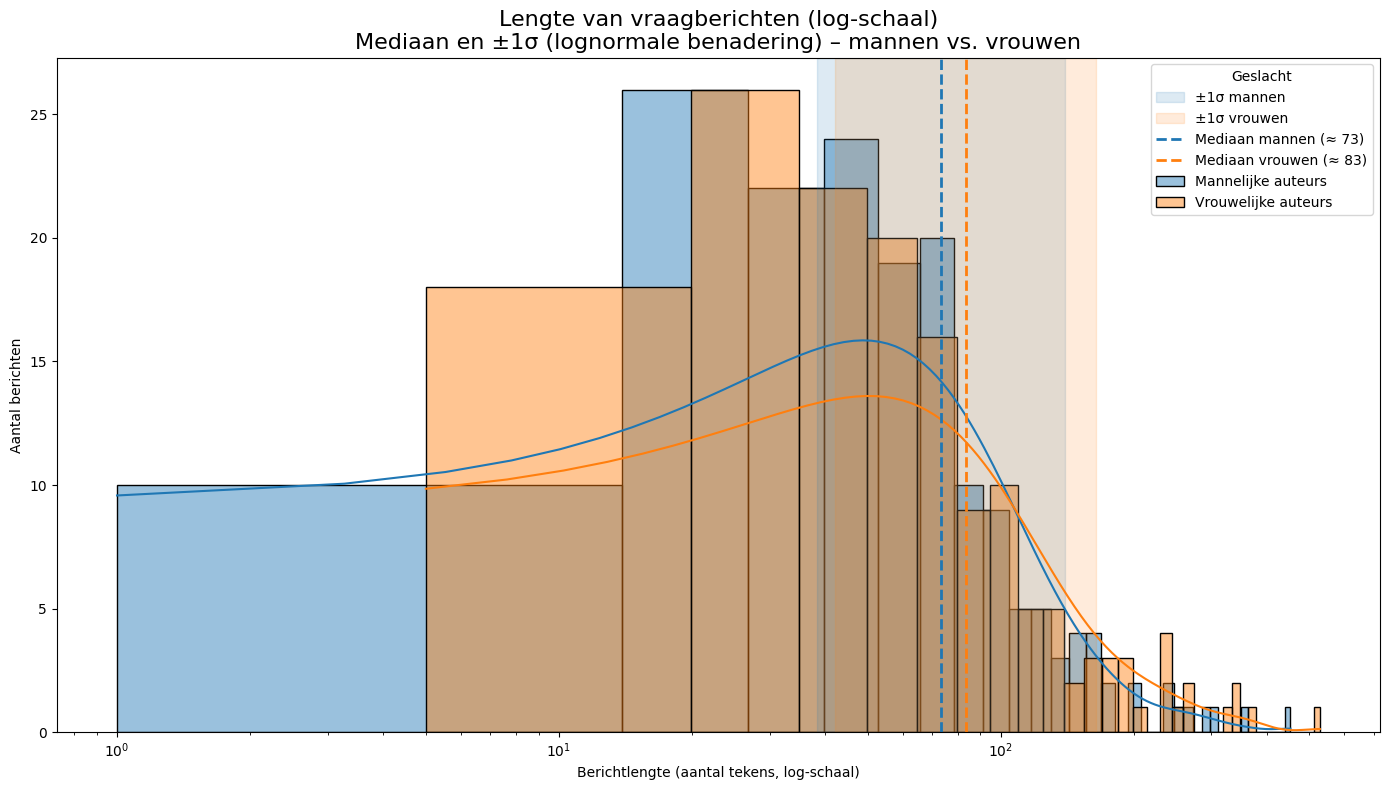

In [ ]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tomllib
import json
from loguru import logger
import warnings
import numpy as np
from scipy.stats import mannwhitneyu


warnings.filterwarnings("ignore", category=FutureWarning)

# --- Load WhatsApp data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning("Datafile does not exist. Run preprocess first!")

df = pd.read_parquet(datafile)

# --- Load author metadata ---
with open("nested_users5.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={'index': 'author'})
    [['author', 'Name', 'Gender']]
)

# --- Map author metadata ---
author_map = dict(zip(author_info_df['author'], author_info_df['Name']))
gender_map = dict(zip(author_info_df['author'], author_info_df['Gender']))

df['author_name'] = df['author'].map(author_map).fillna(df['author'])
df['author_gender'] = df['author'].map(gender_map).fillna('Unknown')

# --- Filter question messages ---
df_q = df[df['message'].str.endswith('?')].copy()

# --- Clean message lengths ---
df_q = df_q[
    (df_q['msg_length'] > 0) &
    (df_q['msg_length'] <= 800)
]

# --- Split by gender ---
df_male = df_q[df_q['author_gender'] == 'Male']
df_female = df_q[df_q['author_gender'] == 'Female']

###################

# ====================================================
# --- Statistische analyse (inferentie)
# ====================================================

# --- Ruwe data arrays ---
male_lengths = df_male['msg_length'].values
female_lengths = df_female['msg_length'].values

print("Aantal berichten:")
print(f"  Mannen  : {len(male_lengths)}")
print(f"  Vrouwen : {len(female_lengths)}\n")

# --- Robuuste descriptives ---
median_male_emp = np.median(male_lengths)
median_female_emp = np.median(female_lengths)

iqr_male = np.percentile(male_lengths, 75) - np.percentile(male_lengths, 25)
iqr_female = np.percentile(female_lengths, 75) - np.percentile(female_lengths, 25)

print("Robuuste statistieken:")
print(f"  Mediaan mannen   : {median_male_emp:.1f} (IQR = {iqr_male:.1f})")
print(f"  Mediaan vrouwen  : {median_female_emp:.1f} (IQR = {iqr_female:.1f})\n")

# ----------------------------------------------------
# Mann–Whitney U-test
# ----------------------------------------------------
u_stat, p_value = mannwhitneyu(
    female_lengths,
    male_lengths,
    alternative="two-sided"
)

print("Mann–Whitney U-test:")
print(f"  U-statistiek : {u_stat:.1f}")
print(f"  p-waarde     : {p_value:.6f}\n")

# ----------------------------------------------------
# Effect size: Cliff's delta
# ----------------------------------------------------
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (nx * ny)

delta = cliffs_delta(female_lengths, male_lengths)

print("Effect size:")
print(f"  Cliff’s delta = {delta:.3f}")

if abs(delta) < 0.147:
    interpretation = "verwaarloosbaar effect"
elif abs(delta) < 0.33:
    interpretation = "klein effect"
elif abs(delta) < 0.474:
    interpretation = "middelgroot effect"
else:
    interpretation = "groot effect"

print(f"  Interpretatie : {interpretation}\n")

# ----------------------------------------------------
# Bootstrap 95% CI voor verschil in medianen
# ----------------------------------------------------
def bootstrap_median_diff(x, y, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n):
        xs = rng.choice(x, size=len(x), replace=True)
        ys = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.median(xs) - np.median(ys))
    return np.percentile(diffs, [2.5, 97.5])

ci_low, ci_high = bootstrap_median_diff(female_lengths, male_lengths)

print("Bootstrap 95% betrouwbaarheidsinterval:")
print(f"  Verschil medianen (vrouw - man): [{ci_low:.1f}, {ci_high:.1f}]")




##################

# ====================================================
# --- Lognormal statistics (per gender)
# ====================================================

# Mean & std on original scale
mean_male = df_male['msg_length'].mean()
std_male = df_male['msg_length'].std()

mean_female = df_female['msg_length'].mean()
std_female = df_female['msg_length'].std()

# Log-scale parameters (approximation)
log_mu_male = np.log(mean_male)
log_sigma_male = np.log(1 + std_male / mean_male)

log_mu_female = np.log(mean_female)
log_sigma_female = np.log(1 + std_female / mean_female)

# Median (lognormal)
# median_male = np.exp(log_mu_male)
# median_female = np.exp(log_mu_female)
median_male = np.median(df_male['msg_length'])
median_female = np.median(df_female['msg_length'])


# ±1σ bands (back to original scale)
lower_1s_male = np.exp(log_mu_male - log_sigma_male)
upper_1s_male = np.exp(log_mu_male + log_sigma_male)

lower_1s_female = np.exp(log_mu_female - log_sigma_female)
upper_1s_female = np.exp(log_mu_female + log_sigma_female)

# ====================================================
# --- Plot
# ====================================================

BW = 1.6
BINS = 35

plt.figure(figsize=(14, 8))

# --- Histograms + KDE ---
sns.histplot(
    df_male['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Mannelijke auteurs'
)

sns.histplot(
    df_female['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Vrouwelijke auteurs'
)

# --- ±1σ shaded bands ---
plt.axvspan(
    lower_1s_male,
    upper_1s_male,
    color='tab:blue',
    alpha=0.15,
    label='±1σ mannen'
)

plt.axvspan(
    lower_1s_female,
    upper_1s_female,
    color='tab:orange',
    alpha=0.15,
    label='±1σ vrouwen'
)

# --- Median lines ---
plt.axvline(
    median_male,
    color='tab:blue',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan mannen (≈ {median_male:.0f})"
)

plt.axvline(
    median_female,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan vrouwen (≈ {median_female:.0f})"
)

# --- Log scale ---
plt.xscale('log')

plt.title(
    "Lengte van vraagberichten (log-schaal)\n"
    "Mediaan en ±1σ (lognormale benadering) – mannen vs. vrouwen",
    fontsize=16
)
plt.xlabel("Berichtlengte (aantal tekens, log-schaal)")
plt.ylabel("Aantal berichten")
plt.legend(title="Geslacht")

plt.tight_layout()
plt.show()


Aantal berichten:
  Mannen  : 173
  Vrouwen : 155

Robuuste statistieken:
  Mediaan mannen   : 55.0 (IQR = 58.0)
  Mediaan vrouwen  : 55.0 (IQR = 68.0)

Mann–Whitney U-test:
  U-statistiek : 13963.0
  p-waarde     : 0.517419

Effect size:
  Cliff’s delta = 0.041
  Interpretatie : verwaarloosbaar effect

Bootstrap 95% betrouwbaarheidsinterval:
  Verschil medianen (vrouw - man): [-11.0, 14.0]


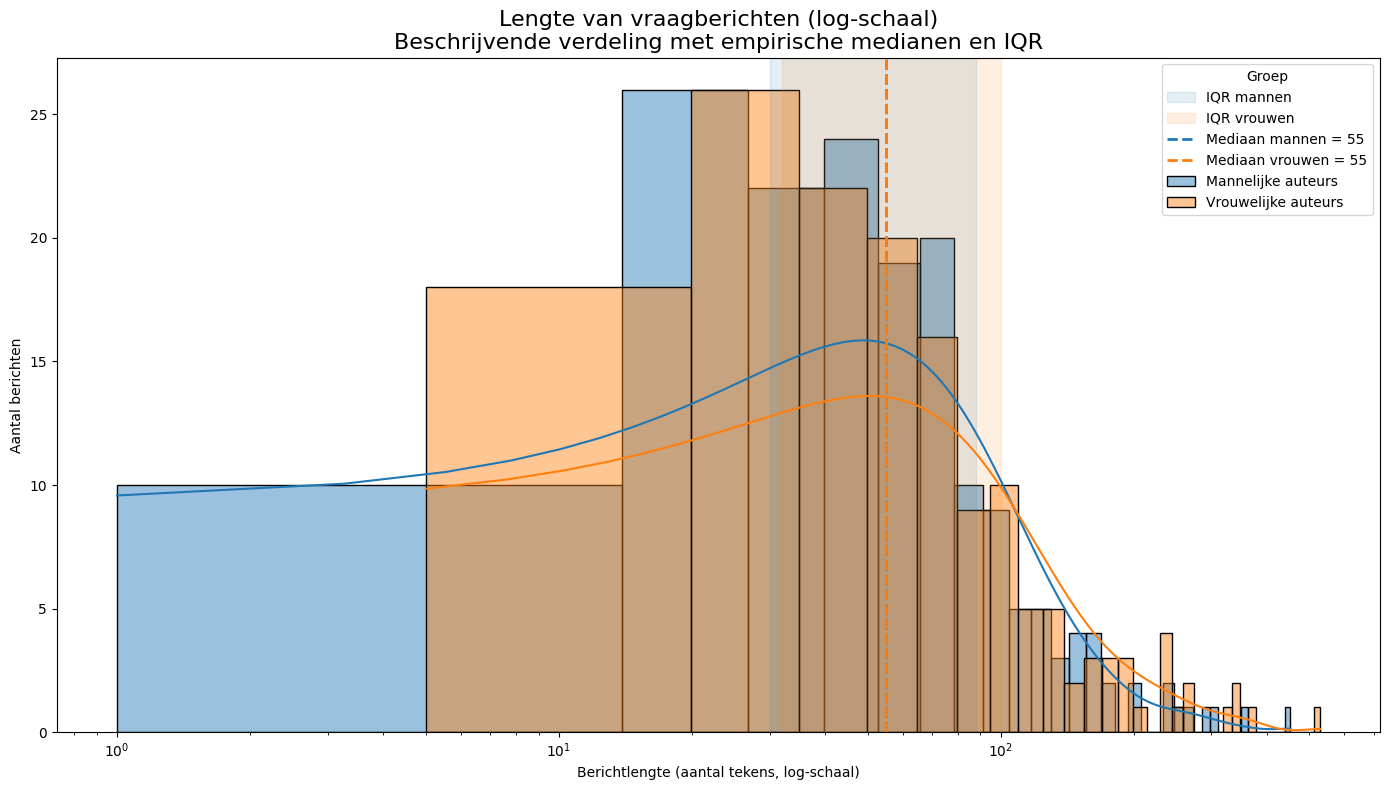

In [13]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tomllib
import json
from loguru import logger
import warnings
import numpy as np
from scipy.stats import mannwhitneyu


warnings.filterwarnings("ignore", category=FutureWarning)

# --- Load WhatsApp data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning("Datafile does not exist. Run preprocess first!")

df = pd.read_parquet(datafile)

# --- Load author metadata ---
with open("nested_users5.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={'index': 'author'})
    [['author', 'Name', 'Gender']]
)

# --- Map author metadata ---
author_map = dict(zip(author_info_df['author'], author_info_df['Name']))
gender_map = dict(zip(author_info_df['author'], author_info_df['Gender']))

df['author_name'] = df['author'].map(author_map).fillna(df['author'])
df['author_gender'] = df['author'].map(gender_map).fillna('Unknown')

# --- Filter question messages ---
df_q = df[df['message'].str.endswith('?')].copy()

# --- Clean message lengths ---
df_q = df_q[
    (df_q['msg_length'] > 0) &
    (df_q['msg_length'] <= 800)
]

# --- Split by gender ---
df_male = df_q[df_q['author_gender'] == 'Male']
df_female = df_q[df_q['author_gender'] == 'Female']

###################

# ====================================================
# --- Statistische analyse (inferentie)
# ====================================================

# --- Ruwe data arrays ---
male_lengths = df_male['msg_length'].values
female_lengths = df_female['msg_length'].values

print("Aantal berichten:")
print(f"  Mannen  : {len(male_lengths)}")
print(f"  Vrouwen : {len(female_lengths)}\n")

# --- Robuuste descriptives ---
median_male_emp = np.median(male_lengths)
median_female_emp = np.median(female_lengths)

iqr_male = np.percentile(male_lengths, 75) - np.percentile(male_lengths, 25)
iqr_female = np.percentile(female_lengths, 75) - np.percentile(female_lengths, 25)

print("Robuuste statistieken:")
print(f"  Mediaan mannen   : {median_male_emp:.1f} (IQR = {iqr_male:.1f})")
print(f"  Mediaan vrouwen  : {median_female_emp:.1f} (IQR = {iqr_female:.1f})\n")

# ----------------------------------------------------
# Mann–Whitney U-test
# ----------------------------------------------------
u_stat, p_value = mannwhitneyu(
    female_lengths,
    male_lengths,
    alternative="two-sided"
)

print("Mann–Whitney U-test:")
print(f"  U-statistiek : {u_stat:.1f}")
print(f"  p-waarde     : {p_value:.6f}\n")

# ----------------------------------------------------
# Effect size: Cliff's delta
# ----------------------------------------------------
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (nx * ny)

delta = cliffs_delta(female_lengths, male_lengths)

print("Effect size:")
print(f"  Cliff’s delta = {delta:.3f}")

if abs(delta) < 0.147:
    interpretation = "verwaarloosbaar effect"
elif abs(delta) < 0.33:
    interpretation = "klein effect"
elif abs(delta) < 0.474:
    interpretation = "middelgroot effect"
else:
    interpretation = "groot effect"

print(f"  Interpretatie : {interpretation}\n")

# ----------------------------------------------------
# Bootstrap 95% CI voor verschil in medianen
# ----------------------------------------------------
def bootstrap_median_diff(x, y, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n):
        xs = rng.choice(x, size=len(x), replace=True)
        ys = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.median(xs) - np.median(ys))
    return np.percentile(diffs, [2.5, 97.5])

ci_low, ci_high = bootstrap_median_diff(female_lengths, male_lengths)

print("Bootstrap 95% betrouwbaarheidsinterval:")
print(f"  Verschil medianen (vrouw - man): [{ci_low:.1f}, {ci_high:.1f}]")




##################

# ====================================================
# --- Lognormal statistics (per gender)
# ====================================================

# Mean & std on original scale
mean_male = df_male['msg_length'].mean()
std_male = df_male['msg_length'].std()

mean_female = df_female['msg_length'].mean()
std_female = df_female['msg_length'].std()

# Log-scale parameters (approximation)
log_mu_male = np.log(mean_male)
log_sigma_male = np.log(1 + std_male / mean_male)

log_mu_female = np.log(mean_female)
log_sigma_female = np.log(1 + std_female / mean_female)

# Median (lognormal)
# median_male = np.exp(log_mu_male)
# median_female = np.exp(log_mu_female)
median_male = np.median(df_male['msg_length'])
median_female = np.median(df_female['msg_length'])


# ±1σ bands (back to original scale)
lower_1s_male = np.exp(log_mu_male - log_sigma_male)
upper_1s_male = np.exp(log_mu_male + log_sigma_male)

lower_1s_female = np.exp(log_mu_female - log_sigma_female)
upper_1s_female = np.exp(log_mu_female + log_sigma_female)


# ====================================================
# --- Statistisch correcte plot (beschrijvend)
# ====================================================

BW = 1.6
BINS = 35

# Empirische medianen
median_male = np.median(df_male['msg_length'])
median_female = np.median(df_female['msg_length'])

# IQR (voor visuele spreiding, robuust)
q1_male, q3_male = np.percentile(df_male['msg_length'], [25, 75])
q1_female, q3_female = np.percentile(df_female['msg_length'], [25, 75])

plt.figure(figsize=(14, 8))

# --- Histograms + KDE (beschrijvend) ---
sns.histplot(
    df_male['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Mannelijke auteurs'
)

sns.histplot(
    df_female['msg_length'],
    bins=BINS,
    stat='count',
    kde=True,
    kde_kws={"bw_adjust": BW},
    alpha=0.45,
    label='Vrouwelijke auteurs'
)

# --- IQR banden (robuste spreiding, geen aannames) ---
plt.axvspan(
    q1_male,
    q3_male,
    color='tab:blue',
    alpha=0.12,
    label='IQR mannen'
)

plt.axvspan(
    q1_female,
    q3_female,
    color='tab:orange',
    alpha=0.12,
    label='IQR vrouwen'
)

# --- Empirische medianen ---
plt.axvline(
    median_male,
    color='tab:blue',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan mannen = {median_male:.0f}"
)

plt.axvline(
    median_female,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label=f"Mediaan vrouwen = {median_female:.0f}"
)

# --- Log scale (alleen voor visualisatie) ---
plt.xscale('log')

plt.title(
    "Lengte van vraagberichten (log-schaal)\n"
    "Beschrijvende verdeling met empirische medianen en IQR",
    fontsize=16
)
plt.xlabel("Berichtlengte (aantal tekens, log-schaal)")
plt.ylabel("Aantal berichten")
plt.legend(title="Groep")

plt.tight_layout()
plt.show()


Datasetoverzicht:
  Totaal aantal berichten in chat : 4565
  Totaal aantal deelnemers        : 78
    ├─ Mannen                     : 41
    └─ Vrouwen                    : 37
  Aantal vragen                   : 328
    ├─ Mannen                     : 173
    └─ Vrouwen                    : 155

Robuuste statistieken:
  Mediaan mannen   : 55.0 (IQR = 58.0)
  Mediaan vrouwen  : 55.0 (IQR = 68.0)

Mann–Whitney U-test:
  U-statistiek : 13963.0
  p-waarde     : 0.517419

Effect size:
  Cliff’s delta = 0.041
  Interpretatie : verwaarloosbaar effect

Bootstrap 95% betrouwbaarheidsinterval:
  Verschil medianen (vrouw - man): [-11.0, 14.0]


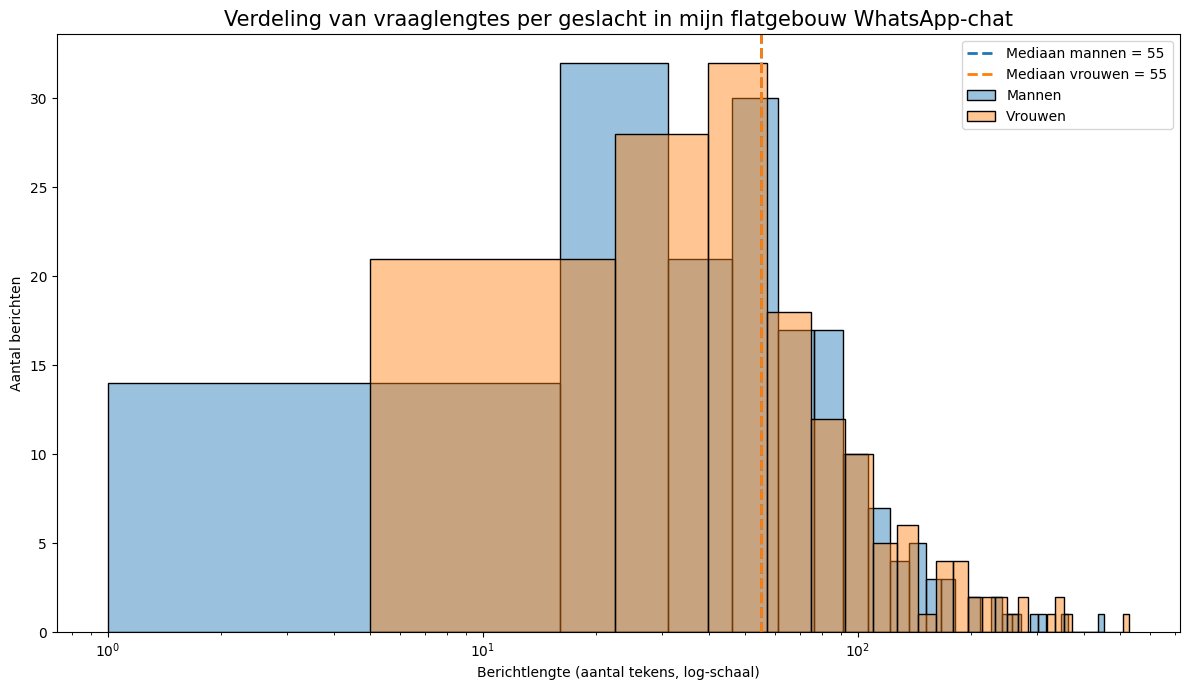

In [20]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tomllib
import json
from loguru import logger
import warnings
import numpy as np
from scipy.stats import mannwhitneyu


warnings.filterwarnings("ignore", category=FutureWarning)

# --- Load WhatsApp data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning("Datafile does not exist. Run preprocess first!")

df = pd.read_parquet(datafile)

# --- Load author metadata ---
with open("resident_metadata.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={'index': 'author'})
    [['author', 'Name', 'Gender']]
)

# --- Map author metadata ---
author_map = dict(zip(author_info_df['author'], author_info_df['Name']))
gender_map = dict(zip(author_info_df['author'], author_info_df['Gender']))

df['author_name'] = df['author'].map(author_map).fillna(df['author'])
df['author_gender'] = df['author'].map(gender_map).fillna('Unknown')

# --- Filter question messages ---
df_q = df[df['message'].str.endswith('?')].copy()

# --- Clean message lengths ---
df_q = df_q[
    (df_q['msg_length'] > 0) &
    (df_q['msg_length'] <= 800)
]

# --- Split by gender ---
df_male = df_q[df_q['author_gender'] == 'Male']
df_female = df_q[df_q['author_gender'] == 'Female']

###################

# ====================================================
# --- Statistische analyse (inferentie)
# ====================================================

# --- Ruwe data arrays ---
male_lengths = df_male['msg_length'].values
female_lengths = df_female['msg_length'].values

# ----------------------------------------------------
# Dataset context
# ----------------------------------------------------
total_messages = len(df)
total_questions = len(df_q)

n_male = len(male_lengths)
n_female = len(female_lengths)

# print("Aantal berichten:")
# print(f"  Mannen  : {len(male_lengths)}")
# print(f"  Vrouwen : {len(female_lengths)}\n")

# --- Aantal personen per geslacht ---
n_men = (author_info_df['Gender'] == 'Male').sum()
n_women = (author_info_df['Gender'] == 'Female').sum()

# print("Datasetoverzicht:")
# print(f"  Totaal aantal berichten in chat : {total_messages}")
# print(f"  Aantal vragen                  : {total_questions}")
# print(f"    ├─ Mannen                    : {n_male}")
# print(f"    └─ Vrouwen                   : {n_female}\n")

print("Datasetoverzicht:")
print(f"  Totaal aantal berichten in chat : {len(df)}")
print(f"  Totaal aantal deelnemers        : {n_men + n_women}")
print(f"    ├─ Mannen                     : {n_men}")
print(f"    └─ Vrouwen                    : {n_women}")
print(f"  Aantal vragen                   : {len(df_q)}")
print(f"    ├─ Mannen                     : {len(df_male)}")
print(f"    └─ Vrouwen                    : {len(df_female)}\n")


# --- Robuuste descriptives ---
median_male_emp = np.median(male_lengths)
median_female_emp = np.median(female_lengths)

iqr_male = np.percentile(male_lengths, 75) - np.percentile(male_lengths, 25)
iqr_female = np.percentile(female_lengths, 75) - np.percentile(female_lengths, 25)

print("Robuuste statistieken:")
print(f"  Mediaan mannen   : {median_male_emp:.1f} (IQR = {iqr_male:.1f})")
print(f"  Mediaan vrouwen  : {median_female_emp:.1f} (IQR = {iqr_female:.1f})\n")

# ----------------------------------------------------
# Mann–Whitney U-test
# ----------------------------------------------------
u_stat, p_value = mannwhitneyu(
    female_lengths,
    male_lengths,
    alternative="two-sided"
)

print("Mann–Whitney U-test:")
print(f"  U-statistiek : {u_stat:.1f}")
print(f"  p-waarde     : {p_value:.6f}\n")

# ----------------------------------------------------
# Effect size: Cliff's delta
# ----------------------------------------------------
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (nx * ny)

delta = cliffs_delta(female_lengths, male_lengths)

print("Effect size:")
print(f"  Cliff’s delta = {delta:.3f}")

if abs(delta) < 0.147:
    interpretation = "verwaarloosbaar effect"
elif abs(delta) < 0.33:
    interpretation = "klein effect"
elif abs(delta) < 0.474:
    interpretation = "middelgroot effect"
else:
    interpretation = "groot effect"

print(f"  Interpretatie : {interpretation}\n")

# ----------------------------------------------------
# Bootstrap 95% CI voor verschil in medianen
# ----------------------------------------------------
def bootstrap_median_diff(x, y, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n):
        xs = rng.choice(x, size=len(x), replace=True)
        ys = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.median(xs) - np.median(ys))
    return np.percentile(diffs, [2.5, 97.5])

ci_low, ci_high = bootstrap_median_diff(female_lengths, male_lengths)

print("Bootstrap 95% betrouwbaarheidsinterval:")
print(f"  Verschil medianen (vrouw - man): [{ci_low:.1f}, {ci_high:.1f}]")




##################

# ====================================================
# --- Lognormal statistics (per gender)
# ====================================================

# Mean & std on original scale
mean_male = df_male['msg_length'].mean()
std_male = df_male['msg_length'].std()

mean_female = df_female['msg_length'].mean()
std_female = df_female['msg_length'].std()

# Log-scale parameters (approximation)
log_mu_male = np.log(mean_male)
log_sigma_male = np.log(1 + std_male / mean_male)

log_mu_female = np.log(mean_female)
log_sigma_female = np.log(1 + std_female / mean_female)

# Median (lognormal)
# median_male = np.exp(log_mu_male)
# median_female = np.exp(log_mu_female)
median_male = np.median(df_male['msg_length'])
median_female = np.median(df_female['msg_length'])


# ±1σ bands (back to original scale)
lower_1s_male = np.exp(log_mu_male - log_sigma_male)
upper_1s_male = np.exp(log_mu_male + log_sigma_male)

lower_1s_female = np.exp(log_mu_female - log_sigma_female)
upper_1s_female = np.exp(log_mu_female + log_sigma_female)


# ====================================================
# --- Statistisch correcte plot (beschrijvend)
# ====================================================

BW = 1.6
BINS = 35

# Empirische medianen
median_male = np.median(df_male['msg_length'])
median_female = np.median(df_female['msg_length'])

# IQR (voor visuele spreiding, robuust)
q1_male, q3_male = np.percentile(df_male['msg_length'], [25, 75])
q1_female, q3_female = np.percentile(df_female['msg_length'], [25, 75])


# 
plt.figure(figsize=(12, 7))

sns.histplot(
    df_male['msg_length'],
    bins=30,
    stat='count',
    element='bars',
    fill=True,
    alpha=0.45,
    label='Mannen'
)

sns.histplot(
    df_female['msg_length'],
    bins=30,
    stat='count',
    element='bars',
    fill=True,
    alpha=0.45,
    label='Vrouwen'
)

# Empirische medianen
plt.axvline(
    median_male,
    color='tab:blue',
    linestyle='--',
    linewidth=2,
    label='Mediaan mannen = 55'
)

plt.axvline(
    median_female,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label='Mediaan vrouwen = 55'
)

plt.xscale('log')

plt.xlabel("Berichtlengte (aantal tekens, log-schaal)")
plt.ylabel("Aantal berichten")

plt.title(
    "Verdeling van vraaglengtes per geslacht in mijn flatgebouw WhatsApp-chat",
    fontsize=15
)

plt.legend()
plt.tight_layout()
plt.show()

